# Polynomial Regression

## 1.Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
Data_set = pd.read_csv("../DataSets/fetch_california_housing.csv")


## 3. Explore DataSet

In [3]:
print("------- Data set Info -----------")
print(Data_set.info())
print("------- Data set Sample -----------")
print(Data_set.head())
print("------- Data set Description -----------")
print(Data_set.describe())
print("------- Data set Columns -----------")
print(Data_set.columns)
print("------- Data set Null Values -----------")
print(Data_set.isnull().sum())
print("------- Data set Shape -----------")
print(Data_set.shape)
print("------- Data set Correlation -----------")
print(Data_set.corr())


------- Data set Info -----------
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
------- Data set Sample -----------
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5

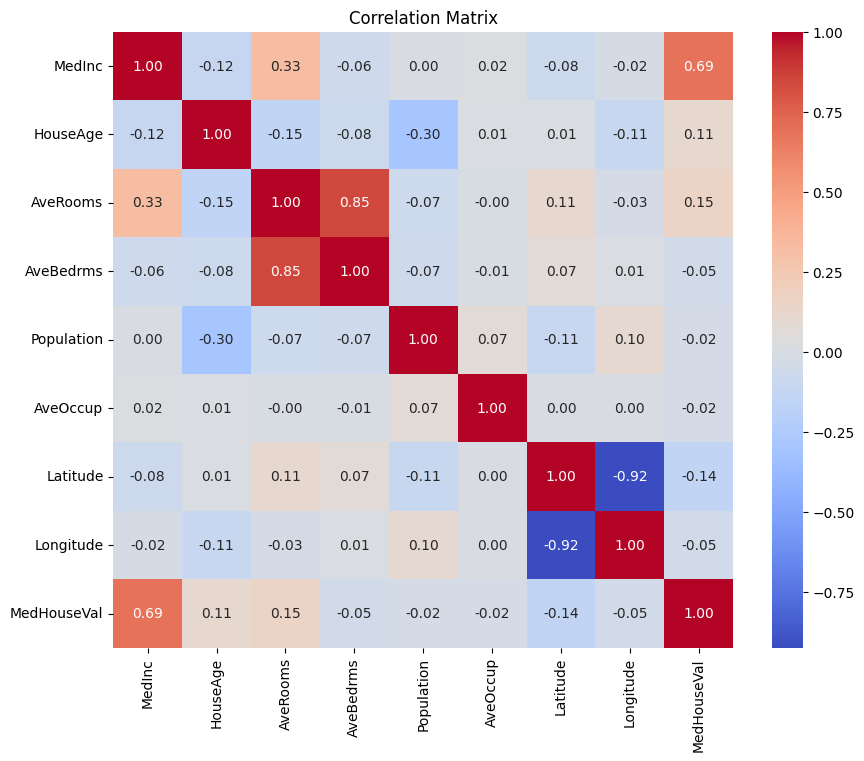

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    Data_set.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [5]:
X = Data_set.drop("MedHouseVal", axis=1)
y = Data_set["MedHouseVal"]

## 4. Split DataSet


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Scale And Transform Features (Polynomial Features)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
degree = 3

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## 6. Train Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](165,)","[0. ,0.91,0.09,...,0.6 ,0.51,0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.876
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,165
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,160
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](165,)","[1241716.26, 377058.15, 30983.57,..., 0.58, 0.43, 0. ]"


## 7. Make Predications

In [10]:
y_pred = model.predict(X_test_poly)

## 8. Evaluation

In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 23.939689582307782
R2 Score: -17.2688687118464


## 9. Visualization

In [12]:
X_sorted = np.sort(X_test, axis=0)
X_sorted_poly = poly.transform(X_sorted)
y_sorted_pred = model.predict(X_sorted_poly)


X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)
# plt.scatter(X_train.ravel(), y_train.ravel(), color='blue', label='Train Data')
# plt.plot(X_sorted, y_sorted_pred, color='red', linewidth=2, label='Polynomial Fit')

# plt.title("Polynomial Regression")
# plt.legend()
# plt.show()

X shape: (20640, 8)
y shape: (20640,)
